# US 10-day basket builder — Refinitiv / LSEG, robust version

This notebook builds a **simple, disciplined 10-day US basket** using your current portfolio snapshot plus Refinitiv / LSEG data.

It is built with **two routes** so you do not get stuck:

- **Route A — Broad universe from Screener**: paste a Screener formula exported from Workspace Screener.
- **Route B — Seeded candidate universe**: use a curated US candidate list, then still let Refinitiv / LSEG pull metadata and price history.

The notebook does all of the following:

1. loads your current open positions,
2. connects to `refinitiv.data` or `lseg.data`,
3. builds a candidate universe,
4. pulls metadata + history,
5. ranks names on a simple tactical model,
6. constructs an 8-name basket with cash and sector caps,
7. produces a rebalance blotter against your current book,
8. defines entry, stop, take-profit, trailing-stop, and kill-switch rules.

The philosophy is simple:

- do not rescue weak names,
- do not overcomplicate the basket,
- do not let one sector sink the whole book,
- keep one macro hedge,
- add only to names that are actually acting well.


## Trading stance

This is a **desk-style tactical book**, not a long-term valuation model.

For the next 10 trading days, the clean expression is usually:

- **Utilities / power** as the stability spine,
- **1–2 energy names** as macro hedge,
- **defensive consumer / quality demand**,
- **one quality health-care / tools name**,
- **no forced rebound trades** in materials, transport, or weak discretionary.

That leads to three operating principles:

1. **Cut complexity first** — fewer names, clearer purpose.
2. **Respect tape, not hope** — only add to confirmed strength.
3. **Constrain risk mechanically** — sector caps, single-name caps, hard stops.


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import date, timedelta

plt.rcParams["figure.figsize"] = (11, 6)

DATA_LIB_NAME = None
rd = None

try:
    import refinitiv.data as rd
    DATA_LIB_NAME = "refinitiv.data"
except Exception:
    try:
        import lseg.data as rd
        DATA_LIB_NAME = "lseg.data"
    except Exception as e:
        raise ImportError(
            "Could not import refinitiv.data or lseg.data. "
            "Install one of them and run again."
        ) from e

print("Using data library:", DATA_LIB_NAME)

try:
    rd.open_session()
except Exception as e:
    print("Warning: open_session() raised an error.")
    print(e)


Using data library: refinitiv.data


## 1) Load the current portfolio snapshot

In [31]:
from pathlib import Path
import pandas as pd
import numpy as np

CSV_PATH = Path("Open Positions Mar 8 2026.csv")
if not CSV_PATH.exists():
    CSV_PATH = Path("/mnt/data/Open Positions Mar 8 2026.csv")

if not CSV_PATH.exists():
    raise FileNotFoundError(
        "Could not find 'Open Positions Mar 8 2026.csv'. "
        "Place the file next to the notebook or update CSV_PATH."
    )

df = pd.read_csv(CSV_PATH)

required_cols = [
    "Symbol", "Description", "Quantity", "LastPrice", "PricePaid",
    "MarketValue", "ProfitLoss", "ProfitLossPercentage"
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

def clean_numeric(series):
    return pd.to_numeric(
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.strip(),
        errors="coerce"
    )

for col in ["Quantity", "LastPrice", "PricePaid", "DayChange", "MarketValue", "ProfitLoss", "ProfitLossPercentage"]:
    if col in df.columns:
        df[col] = clean_numeric(df[col])

df["CostBasis"] = df["MarketValue"] - df["ProfitLoss"]

total_mv = df["MarketValue"].sum()
df["CurrentWeightPct"] = np.where(total_mv > 0, df["MarketValue"] / total_mv * 100, np.nan)
df["PriceGapPct"] = np.where(df["PricePaid"] > 0, (df["LastPrice"] / df["PricePaid"] - 1) * 100, np.nan)

display(
    df[[
        "Symbol", "Description", "Quantity", "LastPrice", "PricePaid",
        "MarketValue", "ProfitLoss", "ProfitLossPercentage",
        "CurrentWeightPct", "PriceGapPct"
    ]].sort_values("ProfitLoss")
)


,Symbol,Description,MarketValue,CurrentWeightPct,ProfitLoss,ProfitLossPercentage
7,MT,ARCELORMITTAL,5.758682e+06,9.462820,-798280.72,-12.17
10,SCCO,Southern Copper Corporation,2.867381e+06,4.711758,-547681.18,-16.04
2,FDX,Fedex Corp,6.185247e+06,10.163764,-408043.75,-6.19
3,FTI,TechnipFMC plc,4.124807e+06,6.777994,-268354.65,-6.11
5,HSY,Hershey Company,5.217505e+06,8.573544,-260423.04,-4.75
9,PCG,PG&E Corp.,5.949619e+06,9.776573,-238901.09,-3.86
6,HWM,Howmet Aerospace Inc,3.877484e+06,6.371585,-185247.38,-4.56
1,EIX,Edison International,6.180080e+06,10.155273,-179993.97,-2.83
12,TPR,Tapestry Inc,2.855316e+06,4.691932,-179460.02,-5.91
4,GRMN,Garmin Ltd,4.969621e+06,8.166215,-133078.41,-2.61


In [32]:
portfolio_summary = pd.DataFrame({
    "Metric": [
        "Number of positions",
        "Total market value",
        "Total P/L",
        "Portfolio return %",
        "Winning positions",
        "Losing positions",
        "Top 3 weight %",
    ],
    "Value": [
        len(df),
        df["MarketValue"].sum(),
        df["ProfitLoss"].sum(),
        df["ProfitLoss"].sum() / df["CostBasis"].sum() * 100,
        int((df["ProfitLoss"] > 0).sum()),
        int((df["ProfitLoss"] < 0).sum()),
        df["CurrentWeightPct"].nlargest(3).sum(),
    ],
})

display(portfolio_summary)


,Metric,Value
0,Number of positions,1.300000e+01
1,Total market value,6.085587e+07
2,Total P/L,-3.086344e+06
3,Portfolio return %,-4.826770e+00
4,Winning positions,2.000000e+00
5,Losing positions,1.100000e+01
6,Top 3 weight %,3.009561e+01


## 2) Configuration

Three important toggles:

- `USE_BROAD_SCREEN`: if `True`, use a Screener formula exported from Workspace Screener.
- `SCREENER_FORMULA`: paste the exported formula here.
- `USE_SEEDED_FALLBACK`: if broad screen is unavailable, use the seeded US watchlist.


In [33]:
LOOKBACK_DAYS = 140
BENCHMARK_RIC = "SPY.P"

FINAL_BASKET_N = 8
TARGET_CASH = 0.10
MAX_SINGLE_NAME_WEIGHT = 0.12

HARD_STOP_PCT = 0.06
TAKE_PROFIT_1_PCT = 0.07
TRAILING_STOP_PCT = 0.045
TIME_STOP_DAYS = 10

USE_BROAD_SCREEN = False
USE_SEEDED_FALLBACK = True

SCREENER_FORMULA = ""

CURRENT_RIC_MAP = {
    "AD": "A.N",
    "EIX": "EIX.N",
    "FDX": "FDX.N",
    "FTI": "FTI.N",
    "GRMN": "GRMN.N",
    "HSY": "HSY.N",
    "HWM": "HWM.N",
    "MT": "MT.N",
    "OMC": "OMC.N",
    "PCG": "PCG.N",
    "SCCO": "SCCO.N",
    "TPL": "TPL.N",
    "TPR": "TPR.N",
}

SEEDED_CANDIDATE_RICS = [
    # current names worth re-checking
    "A.N", "EIX.N", "HSY.N", "HWM.N", "OMC.N", "PCG.N", "TPL.N",

    # utilities / power
    "NEE.N", "DUK.N", "SO.N", "AEP.O", "PEG.N", "XEL.O", "EXC.O",

    # energy
    "XOM.N", "CVX.N", "COP.N", "EOG.N",

    # staples / defensive retail
    "COST.O", "PG.N", "KO.N", "PEP.O", "WMT.N",

    # healthcare / tools
    "ABT.N", "JNJ.N", "MDT.N", "SYK.N", "BSX.N",

    # quality industrials / tech
    "RTX.N", "HON.O", "ETN.N", "TT.N",
    "MSFT.O", "AVGO.O", "ORCL.N"
]

EXCLUDE_SYMBOLS = {"MT", "FTI", "GRMN", "SCCO", "FDX", "TPR"}
EXCLUDE_SECTOR_KEYWORDS = {"materials", "transport", "discretionary", "real estate", "financial"}

# 8 names, 90% invested, 10% cash
SECTOR_SLOT_PLAN = {
    "Utilities": [0.12, 0.10],
    "Energy": [0.12, 0.10],
    "Consumer Staples": [0.11],
    "Health Care": [0.11],
    "Industrials": [0.12],
    "Technology": [0.12],
    "Communication Services": [],
    "Unknown": []
}

assert round(sum(sum(v) for v in SECTOR_SLOT_PLAN.values()) + TARGET_CASH, 6) == 1.00


## 3) Optional helpers — Screener and Search

In [34]:
def make_screener_request(formula_text):
    if not formula_text:
        return None

    try:
        from lseg.data.discovery import Screener
        return Screener(formula_text)
    except Exception:
        pass

    try:
        from refinitiv.data.discovery import Screener
        return Screener(formula_text)
    except Exception:
        pass

    return formula_text


def try_discovery_search(query, top=10):
    try:
        res = rd.discovery.search(
            view=rd.discovery.Views.EQUITY_QUOTES,
            query=query,
            filter="(SearchAllCategoryv2 eq 'Equities')",
            select="DTSubjectName,ExchangeName,RIC,IssueISIN,MktCapCompanyUsd,RCSAssetCategoryLeaf",
            order_by="MktCapCompanyUsd desc",
            top=top
        )
        return pd.DataFrame(res)
    except Exception as e:
        print(f"Search failed for query={query!r}: {e}")
        return pd.DataFrame()

# Example:
# display(try_discovery_search("NextEra Energy", top=5))


## 4) Build the candidate universe

In [35]:
import time
import pandas as pd

META_FIELDS = [
    "TR.CommonName",
    "TR.HeadquartersCountry",
    "TR.TRBCEconomicSector",
    "TR.TRBCBusinessSector",
    "TR.TRBCIndustryGroup",
    "TR.TRBCIndustry",
    "TR.HasESGCoverage",
    "TR.TRESGScore",
    "TR.CompanyMarketCap(Scale=6)",
    "TR.AvgDailyVolume20D",
]

def chunk_list(seq, size):
    for i in range(0, len(seq), size):
        yield seq[i:i + size]

def safe_get_data_chunked(universe, fields, chunk_size=8, sleep_sec=0.35, verbose=True):
    ok_frames = []
    bad_rics = []

    universe = list(pd.Index(universe).dropna())

    for chunk in chunk_list(universe, chunk_size):
        try:
            tmp = rd.get_data(universe=chunk, fields=fields)
            if tmp is not None and not tmp.empty:
                ok_frames.append(tmp)
            if verbose:
                print(f"OK chunk: {chunk}")
            time.sleep(sleep_sec)
        except Exception as e:
            if verbose:
                print(f"Chunk failed: {chunk}")
                print(" ->", e)

            for ric in chunk:
                try:
                    one = rd.get_data(universe=[ric], fields=fields)
                    if one is not None and not one.empty:
                        ok_frames.append(one)
                        if verbose:
                            print(f"   OK single: {ric}")
                    else:
                        bad_rics.append((ric, "Empty result"))
                        if verbose:
                            print(f"   BAD single: {ric} -> Empty result")
                    time.sleep(sleep_sec)
                except Exception as e2:
                    bad_rics.append((ric, str(e2)))
                    if verbose:
                        print(f"   BAD single: {ric} -> {e2}")

    out = pd.concat(ok_frames, ignore_index=True).drop_duplicates() if ok_frames else pd.DataFrame()
    bad_df = pd.DataFrame(bad_rics, columns=["RIC", "Error"])
    return out, bad_df

candidate_meta = None
bad_rics_df = pd.DataFrame(columns=["RIC", "Error"])

if USE_BROAD_SCREEN and SCREENER_FORMULA.strip():
    screen_request = make_screener_request(SCREENER_FORMULA.strip())
    try:
        candidate_meta = rd.get_data(universe=screen_request, fields=META_FIELDS)
        print("Broad Screener route used.")
    except Exception as e:
        print("Broad Screener route failed:", e)
        if not USE_SEEDED_FALLBACK:
            raise

if candidate_meta is None and USE_SEEDED_FALLBACK:
    candidate_meta, bad_rics_df = safe_get_data_chunked(
        universe=SEEDED_CANDIDATE_RICS,
        fields=META_FIELDS,
        chunk_size=8,
        sleep_sec=0.35,
        verbose=True,
    )
    print("Seeded fallback universe used.")

if candidate_meta is None or candidate_meta.empty:
    raise ValueError("Could not build any candidate universe.")

candidate_meta = candidate_meta.copy()
candidate_meta.columns = [str(c) for c in candidate_meta.columns]
display(candidate_meta.head())

if not bad_rics_df.empty:
    print("Bad / failed RICs:")
    display(bad_rics_df)


Candidate RICs before metadata pull: 33


/var/folders/d3/4j2xrjxn06v329lnxwrwmzs80000gn/T/ipykernel_44407/3770969395.py:106:FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.


OK chunk: ['A.N', 'ABT.N', 'AEP.O', 'COP.N', 'COST.O', 'CVX.N', 'DUK.N', 'EIX.N']
OK chunk: ['EXC.O', 'FDX.N', 'FTI.N', 'GRMN.N', 'HSY.N', 'HWM.N', 'JNJ.N', 'KO.N']
OK chunk: ['LIN.N', 'MDT.N', 'MT.N', 'NEE.N', 'OMC.N', 'PCG.N', 'PEG.N', 'PEP.O']
OK chunk: ['PG.N', 'RTX.N', 'SCCO.N', 'SO.N', 'TPL.N', 'TPR.N', 'WMT.N', 'XEL.O']
OK chunk: ['XOM.N']


In [36]:
def normalize_meta_columns(meta_df):
    expected_cols = [
        "RIC", "CommonName", "HQCountry", "Sector", "BusinessSector",
        "IndustryGroup", "Industry", "HasESGCoverage", "ESGScore",
        "MarketCapUSDm", "AvgDailyVolume20D"
    ]

    if meta_df is None:
        return pd.DataFrame(columns=expected_cols)

    if not isinstance(meta_df, pd.DataFrame):
        meta_df = pd.DataFrame(meta_df)

    if meta_df.empty:
        return pd.DataFrame(columns=expected_cols)

    dfm = meta_df.copy()
    rename_map = {}

    for c in dfm.columns:
        cl = str(c).lower()
        if cl in ["instrument", "ric"] or cl.endswith(".ric"):
            rename_map[c] = "RIC"
        elif "common name" in cl:
            rename_map[c] = "CommonName"
        elif "headquarters country" in cl:
            rename_map[c] = "HQCountry"
        elif "economic sector" in cl:
            rename_map[c] = "Sector"
        elif "business sector" in cl:
            rename_map[c] = "BusinessSector"
        elif "industry group" in cl:
            rename_map[c] = "IndustryGroup"
        elif cl.strip() == "trbc industry" or "trbc industry" in cl:
            rename_map[c] = "Industry"
        elif "hasesgcoverage" in cl or "has esg coverage" in cl:
            rename_map[c] = "HasESGCoverage"
        elif "tresgscore" in cl or "esg score" in cl:
            rename_map[c] = "ESGScore"
        elif "companymarketcap" in cl or "market cap" in cl:
            rename_map[c] = "MarketCapUSDm"
        elif "avgdailyvolume20d" in cl or "avg daily volume" in cl:
            rename_map[c] = "AvgDailyVolume20D"

    dfm = dfm.rename(columns=rename_map)

    if "RIC" not in dfm.columns:
        dfm = dfm.rename(columns={dfm.columns[0]: "RIC"})

    keep = [c for c in expected_cols if c in dfm.columns]
    dfm = dfm[keep].copy()

    for col in ["ESGScore", "MarketCapUSDm", "AvgDailyVolume20D"]:
        if col in dfm.columns:
            dfm[col] = pd.to_numeric(dfm[col], errors="coerce")

    dfm = dfm.dropna(subset=["RIC"]).drop_duplicates(subset=["RIC"]).reset_index(drop=True)
    return dfm

candidate_meta = normalize_meta_columns(candidate_meta)
display(candidate_meta.head(10))
print("Candidate universe size:", len(candidate_meta))


,RIC,CommonName,HQCountry,Sector,BusinessSector,IndustryGroup,Industry,PriceClose
0,A.N,Agilent Technologies Inc,<NA>,Healthcare,Healthcare Services & Equipment,Healthcare Equipment & Supplies,Advanced Medical Equipment & Technology,<NA>
1,ABT.N,Abbott Laboratories,<NA>,Healthcare,Healthcare Services & Equipment,Healthcare Equipment & Supplies,"Medical Equipment, Supplies & Distribution",<NA>
2,AEP.O,American Electric Power Company Inc,<NA>,Utilities,Utilities,Electric Utilities & IPPs,Electric Utilities,<NA>
3,COP.N,ConocoPhillips,<NA>,Energy,Energy - Fossil Fuels,Oil & Gas,Oil & Gas Exploration and Production,<NA>
4,COST.O,Costco Wholesale Corp,<NA>,Consumer Cyclicals,Retailers,Diversified Retail,Discount Stores,<NA>
5,CVX.N,Chevron Corp,<NA>,Energy,Energy - Fossil Fuels,Oil & Gas,Integrated Oil & Gas,<NA>
6,DUK.N,Duke Energy Corp,<NA>,Utilities,Utilities,Electric Utilities & IPPs,Electric Utilities,<NA>
7,EIX.N,Edison International,<NA>,Utilities,Utilities,Electric Utilities & IPPs,Electric Utilities,<NA>
8,EXC.O,Exelon Corp,<NA>,Utilities,Utilities,Electric Utilities & IPPs,Electric Utilities,<NA>
9,FDX.N,FedEx Corp,<NA>,Industrials,Transportation,Freight & Logistics Services,"Courier, Postal, Air Freight & Land-based Logi...",<NA>


Candidate universe size: 33


## 5) Robust history pull

In [37]:
start_date = (date.today() - timedelta(days=LOOKBACK_DAYS)).isoformat()
end_date = date.today().isoformat()

def fetch_close_series(ric, start_date, end_date, debug=False):
    hist = rd.get_history(
        universe=ric,
        interval="daily",
        start=start_date,
        end=end_date,
    )

    if hist is None or hist.empty:
        raise ValueError(f"No history returned for {ric}")

    if debug:
        print(f"=== {ric} raw output ===")
        print(type(hist))
        print("index names:", getattr(hist.index, "names", None))
        if hasattr(hist, "columns"):
            print("columns:", list(hist.columns))
        print(hist.head())

    if isinstance(hist, pd.Series):
        s = hist.copy()
        s.name = ric
        s.index = pd.to_datetime(s.index)
        return s.sort_index()

    hist = hist.copy().reset_index()
    hist.columns = [str(c) for c in hist.columns]

    date_candidates = [c for c in hist.columns if "date" in c.lower()]
    date_col = date_candidates[0] if date_candidates else hist.columns[0]

    preferred_patterns = ["close", "trdprc_1", "price close", "priceclose", "trade price"]
    price_col = None
    for c in hist.columns:
        cl = c.lower()
        if c != date_col and any(p in cl for p in preferred_patterns):
            price_col = c
            break

    if price_col is None:
        numeric_cols = hist.select_dtypes(include=[np.number]).columns.tolist()
        numeric_cols = [c for c in numeric_cols if c != date_col]
        if not numeric_cols:
            raise ValueError(f"{ric}: cannot identify price column. Columns={hist.columns.tolist()}")
        price_col = numeric_cols[-1]

    out = hist[[date_col, price_col]].copy()
    out.columns = ["Date", ric]
    out["Date"] = pd.to_datetime(out["Date"], errors="coerce")
    out = out.dropna(subset=["Date", ric]).sort_values("Date")

    return out.set_index("Date")[ric]


In [38]:
rics = candidate_meta["RIC"].dropna().tolist()
all_needed_rics = sorted(set(rics + [BENCHMARK_RIC]))

price_series = []
failed_history = []

for ric in all_needed_rics:
    try:
        s = fetch_close_series(ric, start_date, end_date, debug=False)
        price_series.append(s.rename(ric))
    except Exception as e:
        failed_history.append((ric, str(e)))

if not price_series:
    raise RuntimeError("No price history fetched for candidates/benchmark. Check session, symbols, and entitlements.")

close_wide = pd.concat(price_series, axis=1).sort_index().ffill().dropna(how="all")

if close_wide.empty or BENCHMARK_RIC not in close_wide.columns:
    raise RuntimeError(f"Benchmark {BENCHMARK_RIC} is missing from history pull. Check symbol/entitlements.")

print("History fetched for", close_wide.shape[1], "RICs including benchmark.")
if failed_history:
    failed_df = pd.DataFrame(failed_history, columns=["RIC", "Error"])
    display(failed_df.head(20))

display(close_wide.tail())


/opt/anaconda3/envs/final_project/lib/python3.12/site-packages/refinitiv/data/_tools/_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/envs/final_project/lib/python3.12/site-packages/refinitiv/data/_tools/_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/envs/final_project/lib/python3.12/site-packages/refinitiv/data/_tools/_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) 

History fetched for 34 RICs including benchmark.


,A.N,ABT.N,AEP.O,COP.N,COST.O,CVX.N,DUK.N,EIX.N,EXC.O,FDX.N,...,PG.N,RTX.N,SCCO.N,SO.N,SPY.P,TPL.N,TPR.N,WMT.N,XEL.O,XOM.N
Date,,,,,,,,,,,,,,,,,,,,,
2026-03-02,118.17,114.12,133.29,118.24,1002.77,189.6,131.63,74.42,49.17,387.25,...,163.51,212.16,218.85,97.23,686.38,531.09,156.42,127.08,83.8,154.22
2026-03-03,119.04,113.61,131.92,118.52,1007.77,188.77,131.43,73.86,48.96,382.53,...,159.72,206.52,206.23,96.79,680.33,523.64,154.42,127.92,83.17,151.83
2026-03-04,120.54,113.1,133.52,115.65,1006.74,186.03,131.88,73.89,49.25,384.09,...,158.3,208.82,206.66,97.63,685.13,536.11,156.91,127.76,83.04,149.82
2026-03-05,118.11,111.04,132.04,116.82,982.57,189.9,131.61,71.22,48.77,373.35,...,153.99,203.86,191.87,97.2,681.31,523.31,149.6,123.29,82.38,150.76
2026-03-06,115.07,109.56,131.87,117.07,998.1,189.94,132.5,71.76,49.36,359.1,...,153.63,209.76,184.97,97.48,672.38,525.03,144.15,123.8,82.52,151.21


## 6) Signal engine

In [39]:
returns = close_wide.pct_change()

def max_drawdown(x):
    roll_max = x.cummax()
    dd = x / roll_max - 1
    return dd.min()

bench_ret = returns[BENCHMARK_RIC].dropna()

rows = []
for ric in candidate_meta["RIC"]:
    if ric not in close_wide.columns:
        continue

    px = close_wide[ric].dropna()
    ret = px.pct_change().dropna()

    if len(px) < 65:
        continue

    ma10 = px.tail(10).mean()
    ma20 = px.tail(20).mean()
    ma50 = px.tail(50).mean()

    mom_5 = px.iloc[-1] / px.iloc[-6] - 1 if len(px) >= 6 else np.nan
    mom_20 = px.iloc[-1] / px.iloc[-21] - 1 if len(px) >= 21 else np.nan
    mom_60 = px.iloc[-1] / px.iloc[-61] - 1 if len(px) >= 61 else np.nan
    vol_20 = ret.tail(20).std() * np.sqrt(252) if len(ret) >= 20 else np.nan
    dd_20 = max_drawdown(px.tail(20)) if len(px) >= 20 else np.nan

    beta_20 = np.nan
    aligned = pd.concat([ret.rename("stock"), bench_ret.rename("bench")], axis=1).dropna()
    if len(aligned) >= 20:
        stock20 = aligned["stock"].tail(20)
        bench20 = aligned["bench"].tail(20)
        cov = np.cov(stock20, bench20)[0, 1]
        var = np.var(bench20)
        beta_20 = cov / var if var != 0 else np.nan

    rows.append({
        "RIC": ric,
        "LastPx": px.iloc[-1],
        "MA10": ma10,
        "MA20": ma20,
        "MA50": ma50,
        "AboveMA10": px.iloc[-1] > ma10,
        "AboveMA20": px.iloc[-1] > ma20,
        "AboveMA50": px.iloc[-1] > ma50,
        "Mom5": mom_5,
        "Mom20": mom_20,
        "Mom60": mom_60,
        "Vol20": vol_20,
        "DD20": dd_20,
        "Beta20": beta_20,
    })

signal_df = pd.DataFrame(rows)

def robust_z(s):
    s = s.astype(float)
    med = s.median()
    mad = (s - med).abs().median()
    if mad == 0 or pd.isna(mad):
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - med) / (1.4826 * mad)

if not signal_df.empty:
    signal_df["z_mom20"] = robust_z(signal_df["Mom20"])
    signal_df["z_mom5"] = robust_z(signal_df["Mom5"])
    signal_df["z_mom60"] = robust_z(signal_df["Mom60"])
    signal_df["z_vol20"] = robust_z(signal_df["Vol20"])
    signal_df["z_absdd20"] = robust_z(signal_df["DD20"].abs())
    signal_df["z_beta20"] = robust_z(signal_df["Beta20"].fillna(signal_df["Beta20"].median()))

    signal_df["Score"] = (
        1.45 * signal_df["z_mom20"] +
        0.90 * signal_df["z_mom5"] +
        0.80 * signal_df["z_mom60"] -
        0.35 * signal_df["z_vol20"] -
        0.35 * signal_df["z_absdd20"] -
        0.10 * signal_df["z_beta20"] +
        0.20 * signal_df["AboveMA20"].astype(int) +
        0.20 * signal_df["AboveMA50"].astype(int)
    )

display(signal_df.sort_values("Score", ascending=False).head(20))


,RIC,LastPx,MA10,MA20,MA50,AboveMA10,AboveMA20,AboveMA50,Mom5,Mom20,...,Vol20,DD20,Beta20,z_mom20,z_mom5,z_mom60,z_vol20,z_absdd20,z_beta20,Score
28,TPL.N,525.03,522.111,473.70450,382.3382,True,True,True,0.001411,0.520284,...,0.556945,-0.040699,1.320060,4.981767,0.991128,4.780999,4.591938,-0.541061,1.942712,7.277053
3,COP.N,117.07,114.094,111.98250,103.6514,True,True,True,0.031817,0.115165,...,0.275012,-0.024215,0.198926,0.695951,1.747599,0.525019,0.468814,-1.271485,0.142583,2.974951
6,DUK.N,132.50,130.431,127.80700,122.3118,True,True,True,0.012610,0.073657,...,0.134514,-0.023089,-0.445800,0.256833,1.269735,-0.451168,-1.585896,-1.321396,-0.892609,2.862475
5,CVX.N,189.94,186.963,185.02200,172.3682,True,True,True,0.017027,0.059756,...,0.186597,-0.028361,0.174831,0.109769,1.379634,0.673541,-0.824213,-1.087795,0.103896,2.700643
8,EXC.O,49.36,48.927,47.65600,45.4378,True,True,True,-0.002224,0.120291,...,0.282909,-0.025578,-0.897101,0.750177,0.900693,-0.546688,0.584305,-1.211122,-1.617233,2.033750
2,AEP.O,131.87,132.544,129.12450,122.0993,False,True,True,-0.014572,0.093359,...,0.208186,-0.022804,-0.394959,0.465262,0.593481,-0.544055,-0.508490,-1.334019,-0.810978,1.999408
30,XEL.O,82.52,83.255,81.18350,77.4994,False,True,True,-0.010077,0.084078,...,0.181964,-0.023410,-0.310882,0.367077,0.705313,-0.984139,-0.891963,-1.307181,-0.675981,1.891496
25,RTX.N,209.76,203.773,202.20600,196.9640,True,True,True,0.035238,0.070368,...,0.302865,-0.045908,-0.195284,0.222038,1.832710,0.193679,0.876150,-0.310250,-0.490373,1.698254
27,SO.N,97.48,96.697,94.39550,90.5980,True,True,True,0.001027,0.070268,...,0.248250,-0.041180,-0.659539,0.220980,0.981562,-0.545337,0.077427,-0.519780,-1.235796,1.340068
7,EIX.N,71.76,73.935,71.38650,65.1480,False,True,True,-0.039872,0.126354,...,0.306028,-0.053429,-0.309026,0.814321,-0.035952,0.704394,0.922406,0.023006,-0.673001,1.263425


## 7) Merge metadata + signals + current portfolio

In [40]:
ric_to_symbol_current = {v: k for k, v in CURRENT_RIC_MAP.items()}
current_book_map = df.copy()
current_book_map["RIC"] = current_book_map["Symbol"].map(CURRENT_RIC_MAP)

full = candidate_meta.merge(signal_df, on="RIC", how="inner")
full["CurrentSymbol"] = full["RIC"].map(ric_to_symbol_current)

full = full.merge(
    current_book_map[["RIC", "Symbol", "Description", "Quantity", "LastPrice", "PricePaid", "ProfitLoss", "MarketValue", "ProfitLossPercentage", "CurrentWeightPct"]],
    on="RIC", how="left", suffixes=("", "_Current")
)

for c in ["Quantity", "LastPrice", "PricePaid", "ProfitLoss", "MarketValue", "ProfitLossPercentage", "CurrentWeightPct"]:
    if c in full.columns:
        full[c] = full[c].fillna(0)

if "ESGScore" in full.columns:
    full["ESGScore"] = pd.to_numeric(full["ESGScore"], errors="coerce")
if "MarketCapUSDm" in full.columns:
    full["MarketCapUSDm"] = pd.to_numeric(full["MarketCapUSDm"], errors="coerce")
if "AvgDailyVolume20D" in full.columns:
    full["AvgDailyVolume20D"] = pd.to_numeric(full["AvgDailyVolume20D"], errors="coerce")

display(
    full[[
        "RIC", "CommonName", "Sector", "IndustryGroup", "Industry",
        "ESGScore", "MarketCapUSDm", "AvgDailyVolume20D",
        "CurrentSymbol", "CurrentWeightPct", "Mom5", "Mom20", "Mom60", "Vol20", "DD20", "Score"
    ]].sort_values("Score", ascending=False).head(25)
)


,RIC,CommonName,Sector,IndustryGroup,Industry,CurrentSymbol,CurrentWeightPct,Mom5,Mom20,Mom60,Vol20,DD20,Score
28,TPL.N,Texas Pacific Land Corp,Energy,Oil & Gas,Oil & Gas Exploration and Production,TPL,3.715038,0.001411,0.520284,0.742069,0.556945,-0.040699,7.277053
3,COP.N,ConocoPhillips,Energy,Oil & Gas,Oil & Gas Exploration and Production,NaN,0.000000,0.031817,0.115165,0.260444,0.275012,-0.024215,2.974951
6,DUK.N,Duke Energy Corp,Utilities,Electric Utilities & IPPs,Electric Utilities,NaN,0.000000,0.012610,0.073657,0.149974,0.134514,-0.023089,2.862475
5,CVX.N,Chevron Corp,Energy,Oil & Gas,Integrated Oil & Gas,NaN,0.000000,0.017027,0.059756,0.277251,0.186597,-0.028361,2.700643
8,EXC.O,Exelon Corp,Utilities,Electric Utilities & IPPs,Electric Utilities,NaN,0.000000,-0.002224,0.120291,0.139165,0.282909,-0.025578,2.033750
2,AEP.O,American Electric Power Company Inc,Utilities,Electric Utilities & IPPs,Electric Utilities,NaN,0.000000,-0.014572,0.093359,0.139463,0.208186,-0.022804,1.999408
30,XEL.O,Xcel Energy Inc,Utilities,Electric Utilities & IPPs,Electric Utilities,NaN,0.000000,-0.010077,0.084078,0.089661,0.181964,-0.023410,1.891496
25,RTX.N,RTX Corp,Industrials,Aerospace & Defense,Aerospace & Defense,NaN,0.000000,0.035238,0.070368,0.222948,0.302865,-0.045908,1.698254
27,SO.N,Southern Co,Utilities,Electric Utilities & IPPs,Electric Utilities,NaN,0.000000,0.001027,0.070268,0.139317,0.248250,-0.041180,1.340068
7,EIX.N,Edison International,Utilities,Electric Utilities & IPPs,Electric Utilities,EIX,10.155273,-0.039872,0.126354,0.280742,0.306028,-0.053429,1.263425


## 8) Tactical filters

In [41]:
def sector_simple(row):
    raw = str(row.get("Sector", "")).strip()
    if not raw or raw == "nan":
        return "Unknown"

    mapping = {
        "Health Care": "Health Care",
        "Energy": "Energy",
        "Utilities": "Utilities",
        "Consumer Non-Cyclicals": "Consumer Staples",
        "Consumer Staples": "Consumer Staples",
        "Industrials": "Industrials",
        "Communication Services": "Communication Services",
        "Technology": "Technology",
        "Basic Materials": "Materials",
        "Materials": "Materials",
        "Consumer Cyclicals": "Consumer Discretionary",
        "Consumer Discretionary": "Consumer Discretionary",
        "Financials": "Financials",
        "Real Estate": "Real Estate",
    }
    return mapping.get(raw, raw)

filtered = full.copy()
filtered["SectorSimple"] = filtered.apply(sector_simple, axis=1)

# Explicit sell-list exclusions
filtered = filtered[~filtered["CurrentSymbol"].fillna("").isin(EXCLUDE_SYMBOLS)].copy()

# Remove unwanted sectors
filtered = filtered[
    ~filtered["SectorSimple"].astype(str).str.lower().apply(
        lambda x: any(k in x for k in EXCLUDE_SECTOR_KEYWORDS)
    )
].copy()

# US-only book
if "HQCountry" in filtered.columns:
    filtered = filtered[
        filtered["HQCountry"].fillna("").isin(["United States", "U.S.A.", "USA", "US"])
        | filtered["HQCountry"].isna()
        | (filtered["HQCountry"] == "")
    ].copy()

# Anti-junk filters
if "HasESGCoverage" in filtered.columns:
    filtered = filtered[
        filtered["HasESGCoverage"].astype(str).str.lower().isin(["true", "1", "yes"])
        | filtered["HasESGCoverage"].isna()
    ].copy()

if "ESGScore" in filtered.columns:
    filtered = filtered[
        filtered["ESGScore"].isna() | (filtered["ESGScore"] >= 50)
    ].copy()

if "MarketCapUSDm" in filtered.columns:
    filtered = filtered[
        filtered["MarketCapUSDm"].isna() | (filtered["MarketCapUSDm"] >= 10000)
    ].copy()

if "AvgDailyVolume20D" in filtered.columns:
    filtered = filtered[
        filtered["AvgDailyVolume20D"].isna() | (filtered["AvgDailyVolume20D"] >= 2_000_000)
    ].copy()

if "LastPx" in filtered.columns:
    filtered = filtered[filtered["LastPx"] >= 10].copy()

# Tactical trend filters: looser than before, to avoid collapsing the universe
filtered = filtered[
    (filtered["Mom60"] > 0) &
    (filtered["Mom20"] > -0.02) &
    (filtered["AboveMA50"] == True)
].copy()

# Add a light ESG quality tilt to final score
if "ESGScore" in filtered.columns:
    def robust_z_local(s):
        s = s.astype(float)
        med = s.median()
        mad = (s - med).abs().median()
        if mad == 0 or pd.isna(mad):
            return pd.Series(np.zeros(len(s)), index=s.index)
        return (s - med) / (1.4826 * mad)

    filtered["z_esg"] = robust_z_local(filtered["ESGScore"].fillna(filtered["ESGScore"].median()))
    filtered["FinalScore"] = filtered["Score"] + 0.20 * filtered["z_esg"]
else:
    filtered["FinalScore"] = filtered["Score"]

display(
    filtered[[
        "RIC", "CommonName", "SectorSimple", "CurrentSymbol", "CurrentWeightPct",
        "ESGScore", "MarketCapUSDm", "AvgDailyVolume20D",
        "Mom5", "Mom20", "Mom60", "Vol20", "DD20", "FinalScore"
    ]].sort_values(["SectorSimple", "FinalScore"], ascending=[True, False]).head(60)
)

sector_availability = (
    filtered.groupby("SectorSimple")
    .agg(
        Names=("RIC", "count"),
        AvgScore=("FinalScore", "mean")
    )
    .sort_values(["Names", "AvgScore"], ascending=[False, False])
)
display(sector_availability)


,RIC,CommonName,SectorSimple,CurrentSymbol,CurrentWeightPct,Mom5,Mom20,Mom60,Vol20,DD20,Score
28,TPL.N,Texas Pacific Land Corp,Energy,TPL,3.715038,0.001411,0.520284,0.742069,0.556945,-0.040699,7.277053
3,COP.N,ConocoPhillips,Energy,NaN,0.000000,0.031817,0.115165,0.260444,0.275012,-0.024215,2.974951
5,CVX.N,Chevron Corp,Energy,NaN,0.000000,0.017027,0.059756,0.277251,0.186597,-0.028361,2.700643
31,XOM.N,Exxon Mobil Corp,Energy,NaN,0.000000,-0.008459,0.035118,0.303759,0.291365,-0.060234,0.528141
25,RTX.N,RTX Corp,Industrials,NaN,0.000000,0.035238,0.070368,0.222948,0.302865,-0.045908,1.698254
6,DUK.N,Duke Energy Corp,Utilities,NaN,0.000000,0.012610,0.073657,0.149974,0.134514,-0.023089,2.862475
8,EXC.O,Exelon Corp,Utilities,NaN,0.000000,-0.002224,0.120291,0.139165,0.282909,-0.025578,2.033750
2,AEP.O,American Electric Power Company Inc,Utilities,NaN,0.000000,-0.014572,0.093359,0.139463,0.208186,-0.022804,1.999408
30,XEL.O,Xcel Energy Inc,Utilities,NaN,0.000000,-0.010077,0.084078,0.089661,0.181964,-0.023410,1.891496
27,SO.N,Southern Co,Utilities,NaN,0.000000,0.001027,0.070268,0.139317,0.248250,-0.041180,1.340068


## 9) Basket builder

The basket is built by sector slots, not by blindly taking the top 8 names overall.

Current target structure:
- Utilities: 2 names
- Energy: 2 names
- Consumer Staples: 1 name
- Health Care: 1 name
- Industrials: 1 name
- Technology: 1 name
- Cash: 10%

This is more aggressive than the earlier defensive version, but still avoids letting one sector dominate the whole book.


In [42]:
basket_rows = []
used_rics = set()
remaining_cash = TARGET_CASH

for sector_name, slot_weights in SECTOR_SLOT_PLAN.items():
    if not slot_weights:
        continue

    sector_pool = filtered[filtered["SectorSimple"] == sector_name].copy()
    sector_pool = sector_pool.sort_values("FinalScore", ascending=False)

    n_take = min(len(slot_weights), len(sector_pool))
    chosen = sector_pool.head(n_take).copy()

    for w, (_, row) in zip(slot_weights[:n_take], chosen.iterrows()):
        row_dict = row.to_dict()
        row_dict["TargetWeight"] = w
        basket_rows.append(row_dict)
        used_rics.add(row["RIC"])

basket = pd.DataFrame(basket_rows)

reserve_pool = filtered[~filtered["RIC"].isin(used_rics)].copy().sort_values("FinalScore", ascending=False)

# If a target sector is thin, fill from the best remaining names while respecting max single-name weight
while len(basket) < FINAL_BASKET_N and len(reserve_pool) > 0:
    candidate = reserve_pool.iloc[0]
    reserve_pool = reserve_pool.iloc[1:].copy()

    extra_weight = min(MAX_SINGLE_NAME_WEIGHT, remaining_cash)
    if extra_weight <= 0:
        break

    row_dict = candidate.to_dict()
    row_dict["TargetWeight"] = extra_weight
    basket = pd.concat([basket, pd.DataFrame([row_dict])], ignore_index=True)
    remaining_cash -= extra_weight

basket = basket.sort_values(["SectorSimple", "TargetWeight"], ascending=[True, False]).reset_index(drop=True)
basket["TargetWeightPct"] = basket["TargetWeight"] * 100

print("Final basket size:", len(basket))
display(
    basket[[
        "RIC", "CommonName", "SectorSimple", "IndustryGroup", "Industry",
        "CurrentSymbol", "CurrentWeightPct", "ESGScore", "MarketCapUSDm",
        "Mom5", "Mom20", "Mom60", "Vol20", "DD20", "FinalScore", "TargetWeightPct"
    ]]
)

print("Remaining cash weight:", round(remaining_cash * 100, 2), "%")


Final basket size: 8


,RIC,CommonName,SectorSimple,IndustryGroup,Industry,CurrentSymbol,CurrentWeightPct,Mom5,Mom20,Mom60,Vol20,DD20,Score,TargetWeightPct
0,TPL.N,Texas Pacific Land Corp,Energy,Oil & Gas,Oil & Gas Exploration and Production,TPL,3.715038,0.001411,0.520284,0.742069,0.556945,-0.040699,7.277053,11.0
1,COP.N,ConocoPhillips,Energy,Oil & Gas,Oil & Gas Exploration and Production,NaN,0.000000,0.031817,0.115165,0.260444,0.275012,-0.024215,2.974951,9.0
2,CVX.N,Chevron Corp,Energy,Oil & Gas,Integrated Oil & Gas,NaN,0.000000,0.017027,0.059756,0.277251,0.186597,-0.028361,2.700643,8.0
3,RTX.N,RTX Corp,Industrials,Aerospace & Defense,Aerospace & Defense,NaN,0.000000,0.035238,0.070368,0.222948,0.302865,-0.045908,1.698254,8.0
4,DUK.N,Duke Energy Corp,Utilities,Electric Utilities & IPPs,Electric Utilities,NaN,0.000000,0.012610,0.073657,0.149974,0.134514,-0.023089,2.862475,12.0
5,EXC.O,Exelon Corp,Utilities,Electric Utilities & IPPs,Electric Utilities,NaN,0.000000,-0.002224,0.120291,0.139165,0.282909,-0.025578,2.033750,11.0
6,AEP.O,American Electric Power Company Inc,Utilities,Electric Utilities & IPPs,Electric Utilities,NaN,0.000000,-0.014572,0.093359,0.139463,0.208186,-0.022804,1.999408,10.0
7,XEL.O,Xcel Energy Inc,Utilities,Electric Utilities & IPPs,Electric Utilities,NaN,0.000000,-0.010077,0.084078,0.089661,0.181964,-0.023410,1.891496,4.0


Remaining cash weight: 0.0 %


In [43]:
reserve_display = reserve_pool.copy()
if not reserve_display.empty:
    reserve_display["ReserveRank"] = np.arange(1, len(reserve_display) + 1)

display(
    reserve_display[[
        "ReserveRank", "RIC", "CommonName", "SectorSimple", "CurrentSymbol",
        "ESGScore", "MarketCapUSDm", "Mom5", "Mom20", "Mom60", "Vol20", "DD20", "FinalScore"
    ]].head(20)
)


,ReserveRank,RIC,CommonName,SectorSimple,CurrentSymbol,Mom5,Mom20,Mom60,Vol20,DD20,Score
27,1,SO.N,Southern Co,Utilities,NaN,0.001027,0.070268,0.139317,0.248250,-0.041180,1.340068
31,2,XOM.N,Exxon Mobil Corp,Energy,NaN,-0.008459,0.035118,0.303759,0.291365,-0.060234,0.528141


## 10) Rebalance blotter versus the current portfolio

In [44]:
portfolio_value = df["MarketValue"].sum()
basket_target_map = dict(zip(basket["RIC"], basket["TargetWeight"]))

all_trade_rics = sorted(set(list(current_book_map["RIC"].dropna()) + list(basket["RIC"])))

trade_rows = []
for ric in all_trade_rics:
    row_current = current_book_map[current_book_map["RIC"] == ric]
    row_meta = full[full["RIC"] == ric]
    target_weight = basket_target_map.get(ric, 0.0)

    current_symbol = row_current["Symbol"].iloc[0] if len(row_current) else ""
    common_name = row_meta["CommonName"].iloc[0] if len(row_meta) else current_symbol
    current_mv = float(row_current["MarketValue"].iloc[0]) if len(row_current) else 0.0
    current_last = float(row_current["LastPrice"].iloc[0]) if len(row_current) else np.nan
    price_for_calc = current_last

    if (pd.isna(price_for_calc) or price_for_calc == 0) and len(row_meta):
        if "LastPx" in row_meta.columns:
            price_for_calc = float(row_meta["LastPx"].iloc[0])
        elif "PriceClose" in row_meta.columns:
            price_for_calc = float(row_meta["PriceClose"].iloc[0])

    target_value = portfolio_value * target_weight
    delta_value = target_value - current_mv

    shares_to_trade = np.nan
    if not pd.isna(price_for_calc) and price_for_calc > 0:
        shares_to_trade = round(delta_value / price_for_calc)

    action = "HOLD"
    if target_value == 0 and current_mv > 0:
        action = "SELL TO ZERO"
    elif target_value > current_mv + 1e-6:
        action = "BUY / ADD"
    elif 0 < target_value < current_mv - 1e-6:
        action = "TRIM"
    elif target_value == 0 and current_mv == 0:
        action = "IGNORE"

    trade_rows.append({
        "RIC": ric,
        "CurrentSymbol": current_symbol,
        "CommonName": common_name,
        "CurrentMarketValue": current_mv,
        "TargetWeightPct": target_weight * 100,
        "TargetValue": target_value,
        "DeltaValue": delta_value,
        "PriceForCalc": price_for_calc,
        "SharesToTrade": shares_to_trade,
        "Action": action,
    })

trade_blotter = pd.DataFrame(trade_rows)
trade_blotter = trade_blotter.sort_values(["Action", "DeltaValue"], ascending=[True, False]).reset_index(drop=True)
display(trade_blotter)


,RIC,CurrentSymbol,CommonName,CurrentMarketValue,TargetWeightPct,TargetValue,DeltaValue,PriceForCalc,SharesToTrade,Action
0,DUK.N,,Duke Energy Corp,0.000000e+00,12.0,7.302705e+06,7.302705e+06,132.50,55115,BUY / ADD
1,EXC.O,,Exelon Corp,0.000000e+00,11.0,6.694146e+06,6.694146e+06,49.36,135619,BUY / ADD
2,AEP.O,,American Electric Power Company Inc,0.000000e+00,10.0,6.085587e+06,6.085587e+06,131.87,46148,BUY / ADD
3,COP.N,,ConocoPhillips,0.000000e+00,9.0,5.477028e+06,5.477028e+06,117.07,46784,BUY / ADD
4,CVX.N,,Chevron Corp,0.000000e+00,8.0,4.868470e+06,4.868470e+06,189.94,25632,BUY / ADD
5,RTX.N,,RTX Corp,0.000000e+00,8.0,4.868470e+06,4.868470e+06,209.76,23210,BUY / ADD
6,TPL.N,TPL,Texas Pacific Land Corp,2.260819e+06,11.0,6.694146e+06,4.433327e+06,525.03,8444,BUY / ADD
7,XEL.O,,Xcel Energy Inc,0.000000e+00,4.0,2.434235e+06,2.434235e+06,82.52,29499,BUY / ADD
8,TPR.N,TPR,Tapestry Inc,2.855316e+06,0.0,0.000000e+00,-2.855316e+06,144.15,-19808,SELL TO ZERO
9,SCCO.N,SCCO,Southern Copper Corp,2.867381e+06,0.0,0.000000e+00,-2.867381e+06,184.97,-15502,SELL TO ZERO


## 11) Execution rules

### Entry
- **Day 1:** put on **65% of target** for basket names already above MA20 and MA50.
- **Day 3–4:** add the remaining **35%** only if:
  - 5-day momentum remains positive,
  - price remains above MA20,
  - the name did not gap hard against you from day 1.

### Exits
- **Hard stop:** `-6%` from average entry.
- **Take profit 1:** trim `1/3` at `+7%`.
- **Trailing stop:** after `+7%`, trail the rest by `4.5%`.
- **Time stop:** if a name is still below `+1%` after **10 trading days** and 5-day momentum is negative, exit it.

### Book-level kill switches
- If basket drawdown from rebalance reaches `-3.5%`, cut the weakest **2 names** by half.
- If basket drawdown reaches `-5%`, reduce gross exposure by another **10%** and move to cash.


In [45]:
basket = basket.copy()
basket["EntryPlan"] = "60% Day 1, 40% Day 3-4 only if Mom5 > 0 and AboveMA20"
basket["HardStop"] = basket["LastPx"] * (1 - HARD_STOP_PCT)
basket["TakeProfit1"] = basket["LastPx"] * (1 + TAKE_PROFIT_1_PCT)
basket["TrailingStopPct"] = TRAILING_STOP_PCT * 100
basket["TimeStopDays"] = TIME_STOP_DAYS

display(
    basket[[
        "RIC", "CommonName", "SectorSimple", "TargetWeightPct",
        "LastPx", "HardStop", "TakeProfit1", "TrailingStopPct", "TimeStopDays", "EntryPlan"
    ]]
)


,RIC,CommonName,SectorSimple,TargetWeightPct,LastPx,HardStop,TakeProfit1,TrailingStopPct,TimeStopDays,EntryPlan
0,TPL.N,Texas Pacific Land Corp,Energy,11.0,525.03,493.5282,561.7821,4.5,10,"60% Day 1, 40% Day 3-4 only if Mom5 > 0 and Ab..."
1,COP.N,ConocoPhillips,Energy,9.0,117.07,110.0458,125.2649,4.5,10,"60% Day 1, 40% Day 3-4 only if Mom5 > 0 and Ab..."
2,CVX.N,Chevron Corp,Energy,8.0,189.94,178.5436,203.2358,4.5,10,"60% Day 1, 40% Day 3-4 only if Mom5 > 0 and Ab..."
3,RTX.N,RTX Corp,Industrials,8.0,209.76,197.1744,224.4432,4.5,10,"60% Day 1, 40% Day 3-4 only if Mom5 > 0 and Ab..."
4,DUK.N,Duke Energy Corp,Utilities,12.0,132.50,124.5500,141.7750,4.5,10,"60% Day 1, 40% Day 3-4 only if Mom5 > 0 and Ab..."
5,EXC.O,Exelon Corp,Utilities,11.0,49.36,46.3984,52.8152,4.5,10,"60% Day 1, 40% Day 3-4 only if Mom5 > 0 and Ab..."
6,AEP.O,American Electric Power Company Inc,Utilities,10.0,131.87,123.9578,141.1009,4.5,10,"60% Day 1, 40% Day 3-4 only if Mom5 > 0 and Ab..."
7,XEL.O,Xcel Energy Inc,Utilities,4.0,82.52,77.5688,88.2964,4.5,10,"60% Day 1, 40% Day 3-4 only if Mom5 > 0 and Ab..."


## 12) Charts

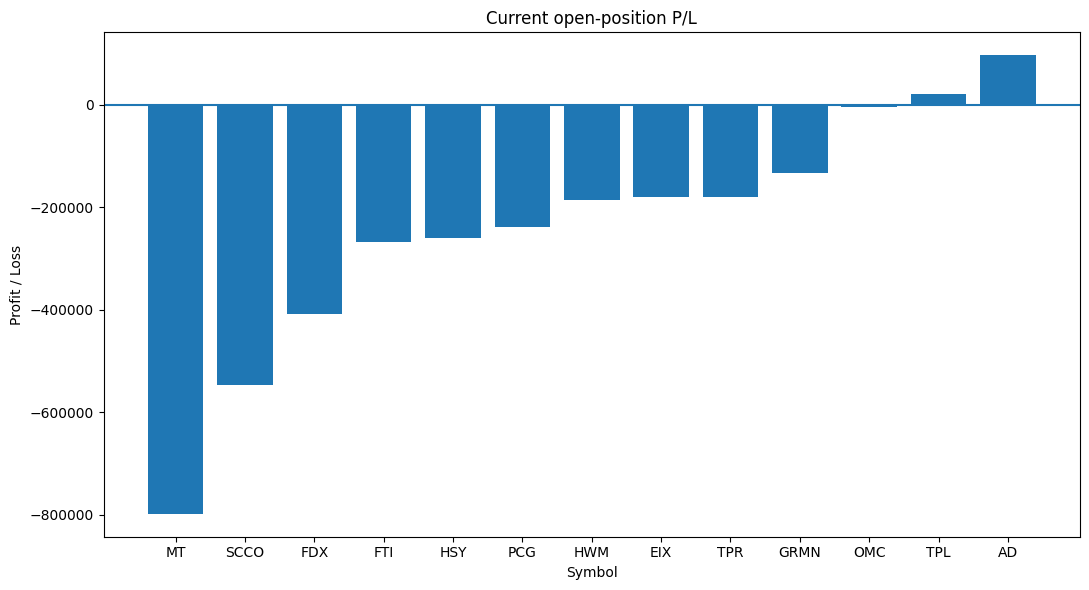

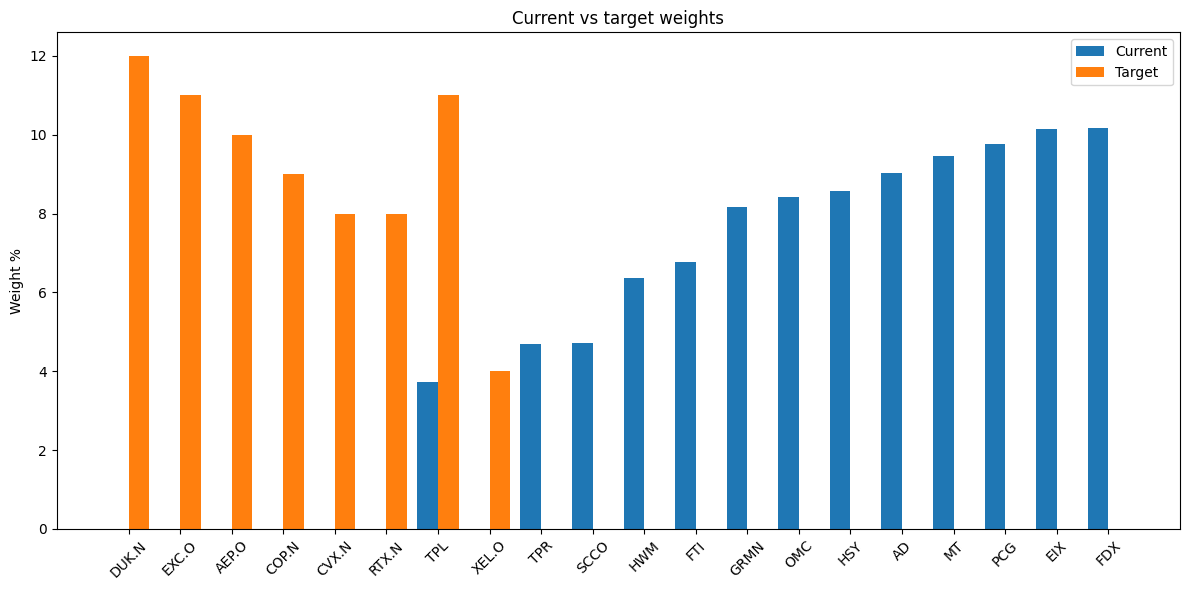

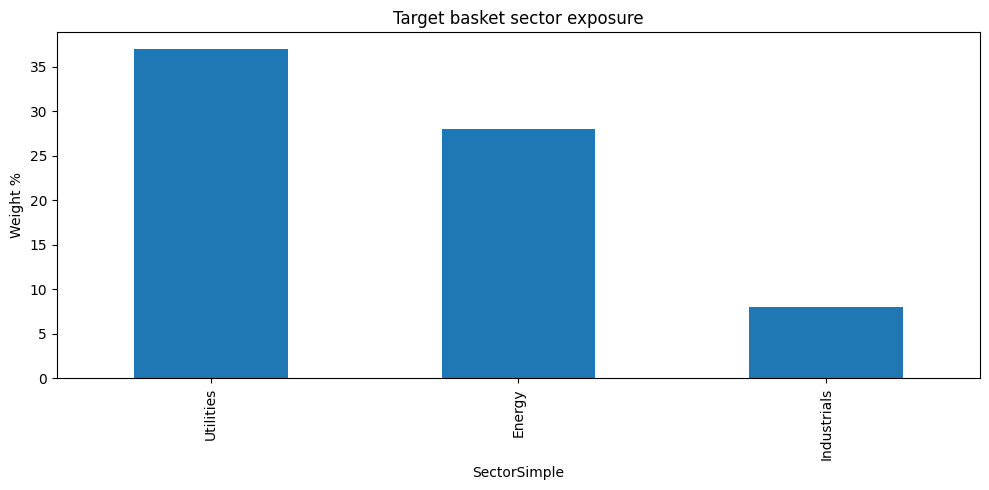

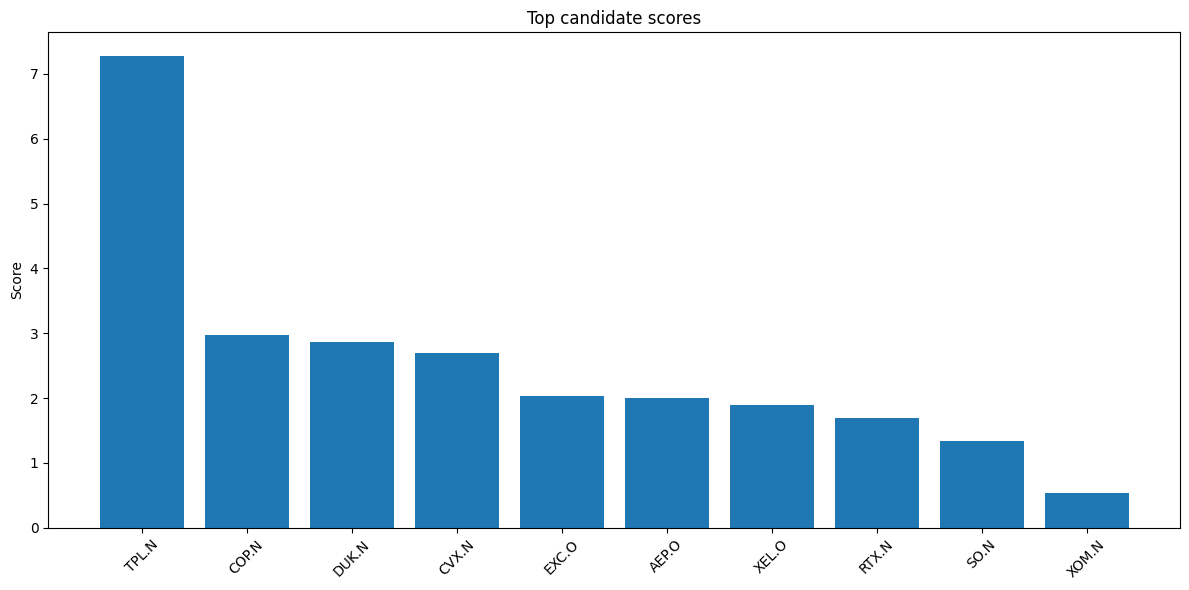

In [46]:
plot_df = df.sort_values("ProfitLoss")
plt.figure()
plt.bar(plot_df["Symbol"], plot_df["ProfitLoss"])
plt.axhline(0)
plt.title("Current open-position P/L")
plt.xlabel("Symbol")
plt.ylabel("Profit / Loss")
plt.tight_layout()
plt.show()

cmp = trade_blotter.copy()
cmp["CurrentWeightPct"] = cmp["CurrentMarketValue"] / portfolio_value * 100
cmp = cmp[(cmp["CurrentWeightPct"] > 0) | (cmp["TargetWeightPct"] > 0)].copy()

x = np.arange(len(cmp))
w = 0.4

plt.figure(figsize=(12, 6))
plt.bar(x - w/2, cmp["CurrentWeightPct"], width=w, label="Current")
plt.bar(x + w/2, cmp["TargetWeightPct"], width=w, label="Target")
labels = cmp["CurrentSymbol"].where(cmp["CurrentSymbol"] != "", cmp["RIC"])
plt.xticks(x, labels, rotation=45)
plt.ylabel("Weight %")
plt.title("Current vs target weights")
plt.legend()
plt.tight_layout()
plt.show()

if len(basket):
    plt.figure(figsize=(10, 5))
    basket.groupby("SectorSimple")["TargetWeightPct"].sum().sort_values(ascending=False).plot(kind="bar")
    plt.title("Target basket sector exposure")
    plt.ylabel("Weight %")
    plt.tight_layout()
    plt.show()

top_rank = filtered.sort_values("FinalScore", ascending=False).head(20)
plt.figure(figsize=(12, 6))
plt.bar(top_rank["RIC"], top_rank["FinalScore"])
plt.xticks(rotation=45)
plt.title("Top candidate scores")
plt.ylabel("FinalScore")
plt.tight_layout()
plt.show()


## 13) Optional CSV exports

In [47]:
OUT_DIR = Path("basket_outputs")
OUT_DIR.mkdir(exist_ok=True)

filtered.sort_values("Score", ascending=False).to_csv(OUT_DIR / "candidate_rankings.csv", index=False)
basket.to_csv(OUT_DIR / "final_basket.csv", index=False)
trade_blotter.to_csv(OUT_DIR / "trade_blotter.csv", index=False)

print(f"Saved outputs to: {OUT_DIR.resolve()}")


Saved outputs to: /Users/phamthanh/Documents/ESSCA | MSc Finance & Data Analyst/14. ESG Portfolio/v1.5/basket_outputs


## Bottom line

The updated 10-day process is:

1. **Cut the obvious losers and the wrong sectors first.**
2. **Require ESG coverage and ESG score >= 50.**
3. **Filter out junk with market cap, liquidity, and price floors.**
4. **Use a profit-tilted score: momentum first, then risk control.**
5. **Build a diversified 8-name basket across 5–6 sectors, not 3 sectors only.**
6. **Stage entries and enforce hard exits without negotiation.**

This version is built to be more competitive for short-term rank climbing, while still avoiding the kind of broad drawdown that hurt the current book.
